In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Hypothesis Testing and Sequential Type I Error Inflation

Let $(\Omega,\mathcal F)$ be a measurable space and let $\mathcal M_1$ denote the set of all probability measures on $(\Omega,\mathcal F)$. Given a null hypothesis $H_0 \subseteq \mathcal M_1$ and an alternative hypothesis $H_1 \subseteq \mathcal M_1$, a **hypothesis test** is a measurable function.
\begin{equation*}
\varphi : \Omega \to \{0,1\},
\end{equation*}
where $\varphi(\omega)=1$ represents rejecting $H_0$ and $\varphi(\omega)=0$ represents not rejecting $H_0$. The function $\varphi$ is also called a **test function** or **decision rule**. The **power function** of the test under a probability measure $P$ is
\begin{equation*}
\beta_\varphi(P) := P(\varphi = 1),
\end{equation*}
so for $P \in H_0$, $\beta_\varphi(P)$ is the **Type I error**, and for $P \in H_1$, it is the probability of correctly rejecting $H_0$.  
The **size** of the test is the largest Type I error across $H_0$:
\begin{equation*}
\text{size}(\varphi) := \sup_{P \in H_0} \beta_\varphi(P),
\end{equation*}
and a **level-$\alpha$ test** satisfies
\begin{equation*}
\sup_{P \in H_0} \beta_\varphi(P) \le \alpha.
\end{equation*}
Note that $\alpha$ is set by the researcher!


\begin{array}{c|c|c} & \text{Do Not Reject } H_0 & \text{Reject } H_0 \\ \hline H_0 \text{ True} & \text{Correct Decision} & \textbf{Type I Error} \\ H_1 \text{ True} & \textbf{Type II Error} & \text{Correct Decision} \end{array}

--- 


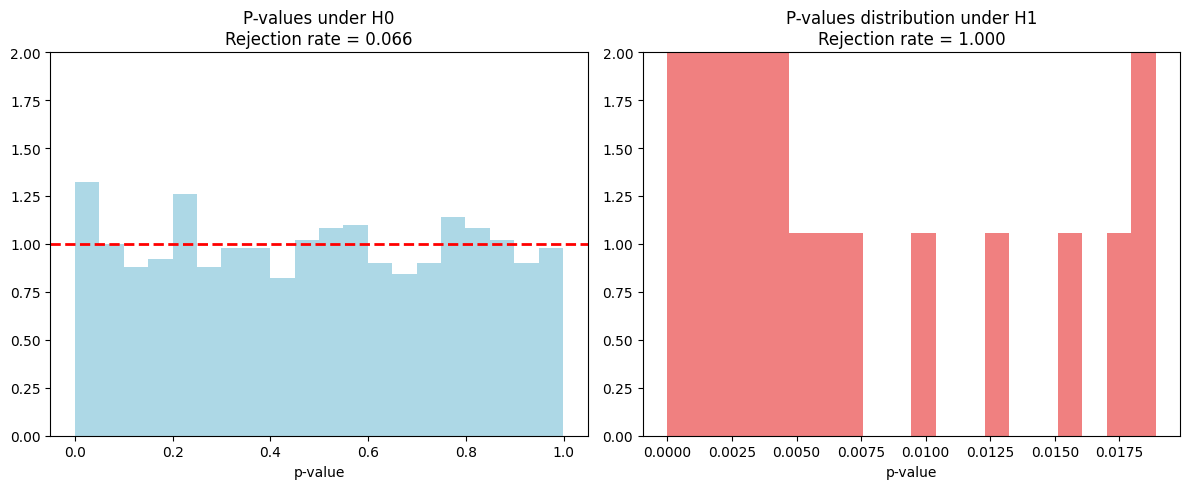

In [ ]:
# Part 1: Histogram simulation
np.random.seed(123)

n = 1000 # number of repetitions
sample_size = 30 

# Considering the simple hypothesis H0: mu = 0  vs H1: mu = 1;

# Generate p-values under H0
p_values_H0 = stats.ttest_1samp(np.random.normal(0, 1, (n, sample_size)), popmean=0, axis=1).pvalue


# Generate p-values under H1
p_values_H1 = stats.ttest_1samp(np.random.normal(1, 1, (n, sample_size)), popmean=0, axis=1).pvalue

# When we say generate under Hi we generate a sample under N(i,1) respectively  

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(p_values_H0, bins=20, density=True, color='lightblue')
axes[0].axhline(1, color='red', linestyle='--', linewidth=2)
axes[0].set_title("P-values under H0")
axes[0].set_xlabel("p-value")
axes[0].set_ylim(0, 2)
axes[0].set_title(f"P-values under H0\nRejection rate = {np.mean(np.array(p_values_H0)<0.05):.3f}")



axes[1].hist(p_values_H1, bins=20, density=True, color='lightcoral')
axes[1].set_title("P-values distribution under H1")
axes[1].set_xlabel("p-value")
axes[1].set_ylim(0, 2)
axes[1].set_title(f"P-values distribution under H1\nRejection rate = {np.mean(np.array(p_values_H1)<0.05):.3f}")

plt.tight_layout()
plt.show()


# The main takeaways:
# Under the null hypothesis, the p-values are approximately uniformly distributed between 0 and 1.
# Under the alternative, p-values concentrate near 0, demonstrating the tests power to detect true effects.



--- 
In a **single test**, the probability of Type I error is controlled by $\alpha$ (e.g., 5%). However, in practice, researchers often perform **sequential or repeated tests** as new data arrives. If we test the same hypothesis $k$ times independently at level $\alpha$, the probability of **not rejecting $H_0$ in any test**, given that $H_0$ is true, is $(1-\alpha)^k$, so the probability of **at least one false rejection** (Type I error) is
\begin{equation*}
P(\text{reject at least one true}) = 1 - (1 - \alpha)^k.
\end{equation*}

**Example:** With $\alpha = 0.05$ and $k = 10$ sequential tests,
\begin{equation*}
P(\text{reject at least one true}) = 1 - (1 - 0.05)^{10} \approx 0.40,
\end{equation*}
so the nominal 5% Type I error inflates to 40%. **Implications:** Sequential peeking or repeated testing without correction greatly increases false positives, invalidating the nominal $\alpha$-level.

---

In [ ]:
# Part 2: Sequential optional stopping test

np.random.seed(42)

def simulate_optional_stopping(mu=0, n_sim=1000, max_n=500, alpha=0.05):
    type1_errors = 0   # Optional stopping
    no_inflated = 0    # No p-hacking baseline

    for _ in range(n_sim):
        # Generate Data with corresponding mu
        data = np.random.normal(mu, 1, max_n)

        # No p-hacking baseline
        p_no_hack = stats.ttest_1samp(data, popmean=0).pvalue
        # Count the number of rejections we find
        if p_no_hack < alpha:
            no_inflated += 1

        # Optional stopping testing every 10 observations
        for n in range(10, max_n + 1, 10):
            p_val = stats.ttest_1samp(data[:n], popmean=0).pvalue
            if p_val < alpha:
                type1_errors += 1
                # If in the experiment we find evidence to reject the null, then it becomes interesting to reject but this inflates type 1 error!
                break

    inflated_alpha = type1_errors / n_sim
    no_inflated_rate = no_inflated / n_sim

    print(f"Type I Error Rate (no p-hacking): {no_inflated_rate:.3f}")
    print(f"Inflated Type I Error Rate (optional stopping): {inflated_alpha:.3f}")

    return np.array([inflated_alpha, no_inflated_rate])


# Run once
simulate_optional_stopping()


Type I Error Rate (no p-hacking): 0.053
Inflated Type I Error Rate (optional stopping): 0.338


array([0.338, 0.053])

Type I Error Rate (no p-hacking): 0.993
Inflated Type I Error Rate (optional stopping): 0.996
Type I Error Rate (no p-hacking): 0.937
Inflated Type I Error Rate (optional stopping): 0.972
Type I Error Rate (no p-hacking): 0.713
Inflated Type I Error Rate (optional stopping): 0.849
Type I Error Rate (no p-hacking): 0.297
Inflated Type I Error Rate (optional stopping): 0.564
Type I Error Rate (no p-hacking): 0.084
Inflated Type I Error Rate (optional stopping): 0.367
Type I Error Rate (no p-hacking): 0.048
Inflated Type I Error Rate (optional stopping): 0.320
Type I Error Rate (no p-hacking): 0.080
Inflated Type I Error Rate (optional stopping): 0.353
Type I Error Rate (no p-hacking): 0.325
Inflated Type I Error Rate (optional stopping): 0.572
Type I Error Rate (no p-hacking): 0.715
Inflated Type I Error Rate (optional stopping): 0.834
Type I Error Rate (no p-hacking): 0.936
Inflated Type I Error Rate (optional stopping): 0.973
Type I Error Rate (no p-hacking): 0.994
Inflated Type I Erro

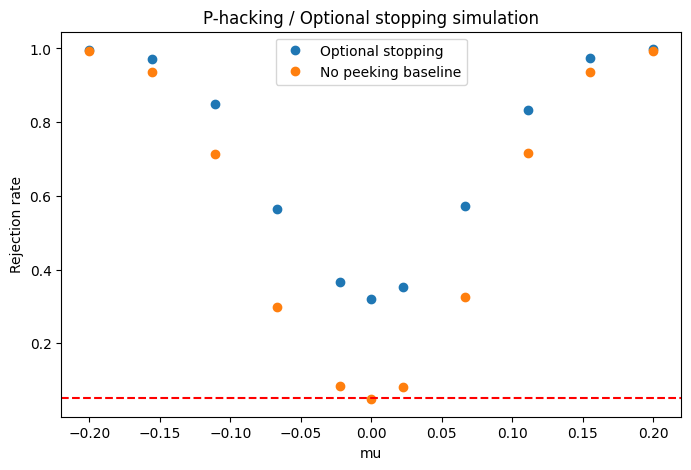

In [5]:
# Part 3: Run across mu values
x = np.linspace(-0.2, 0.2, 10)
x = np.sort(np.unique(np.concatenate([x, [0]]))) # zero to include the case considered before

results = np.array([simulate_optional_stopping(mu) for mu in x])


# Plot rejection rates


plt.figure(figsize=(8, 5))
plt.plot(x, results[:, 0], 'o', label="Optional stopping")
plt.plot(x, results[:, 1], 'o', label="No peeking baseline")

plt.axhline(0.05, color="red", linestyle="--")
plt.xlabel("mu")
plt.ylabel("Rejection rate")
plt.legend()
plt.title("P-hacking / Optional stopping simulation")
plt.show()